# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Creating directory: output/draft3_run//alpha_search...Directory exists. Skipping.
Number of alphas: 5
Testing alpha values: [16, 20, 24, 32, 36]
Running for genes: ['DSE1', 'DSE2', 'DSE3', 'DSE4']
Searching replicate 1 alphas: DSE1...
16,20,24,32,36,
00:00:51.743
Searching replicate 1 alphas: DSE2...
16,20,24,32,36,
00:01:41.965
Searching replicate 1 alphas: DSE3...
16,20,24,32,36,
00:02:32.163
Searching replicate 1 alphas: DSE4...
16,20,24,32,36,
00:03:22.148
Searching replicate 2 alphas: DSE1...
16,20,24,32,36,
00:04:11.706
Searching replicate 2 alphas: DSE2...
16,20,24,32,36,
00:05:02.734
Searching replicate 2 alphas: DSE3...
16,20,24,32,36,
00:05:52.534
Searching replicate 2 alphas: DSE4...
16,20,24,32,36,
00:06:41.204
Results saved to output/draft3_run//alpha_search


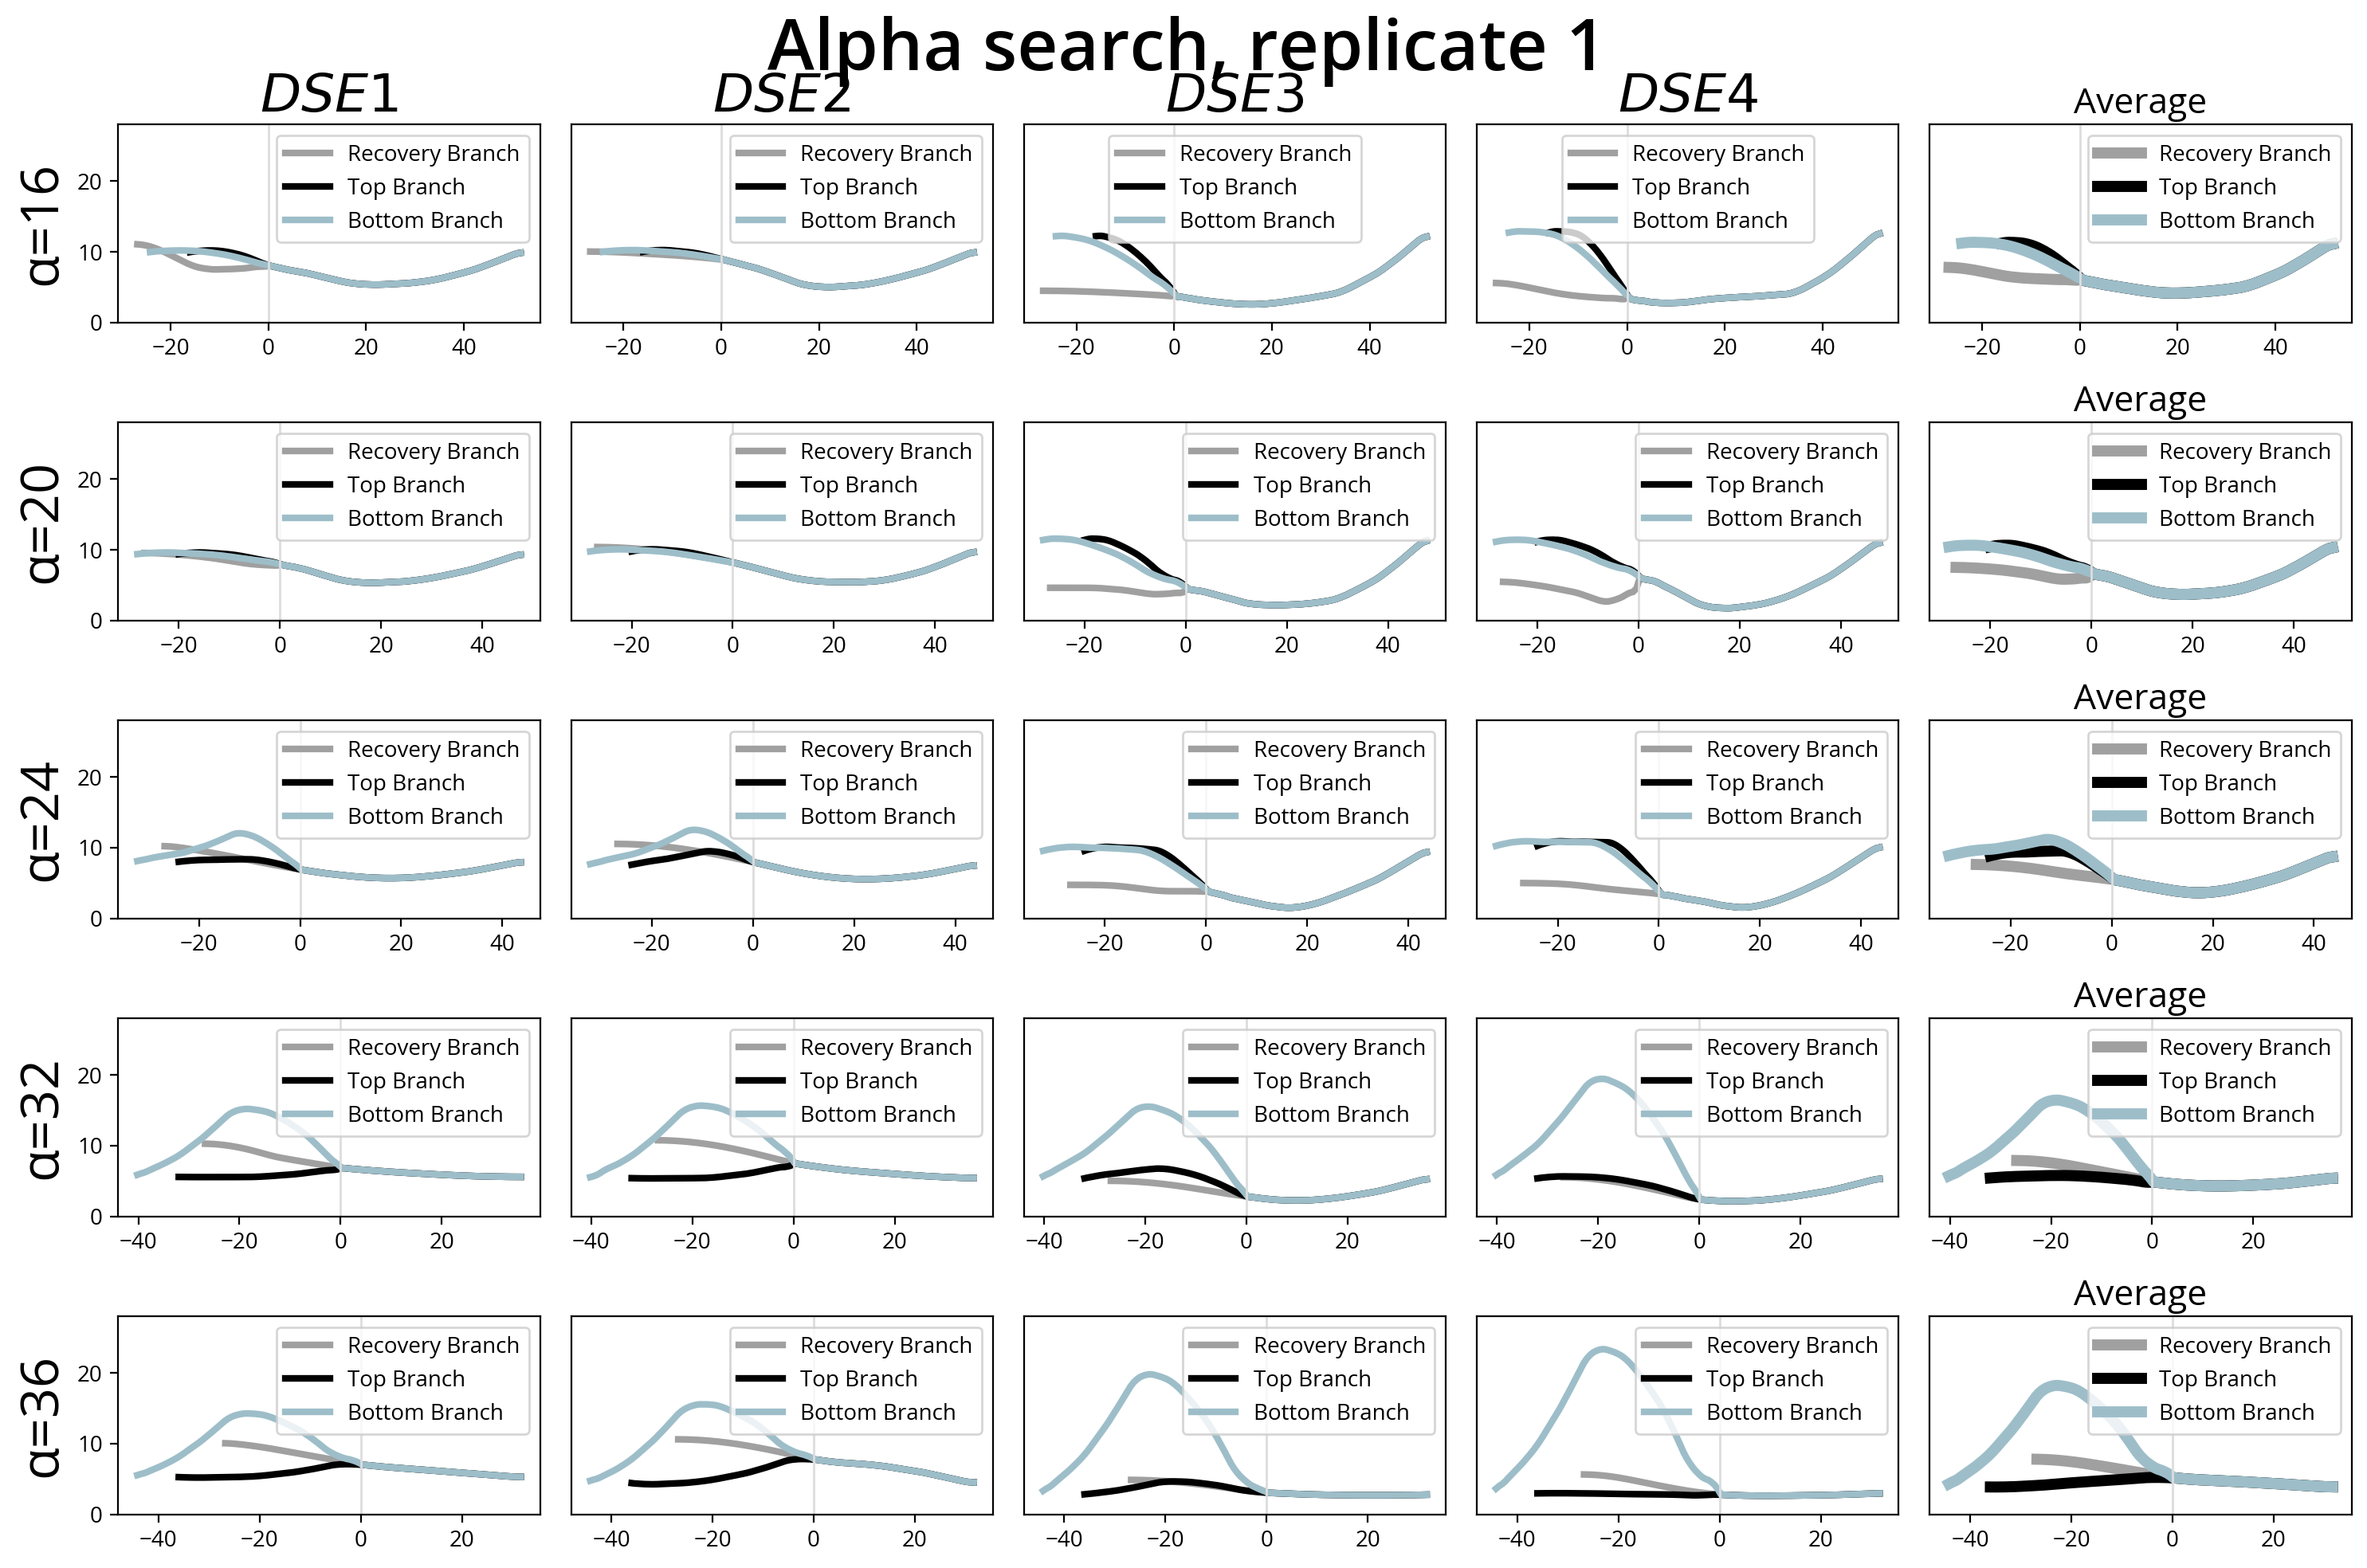

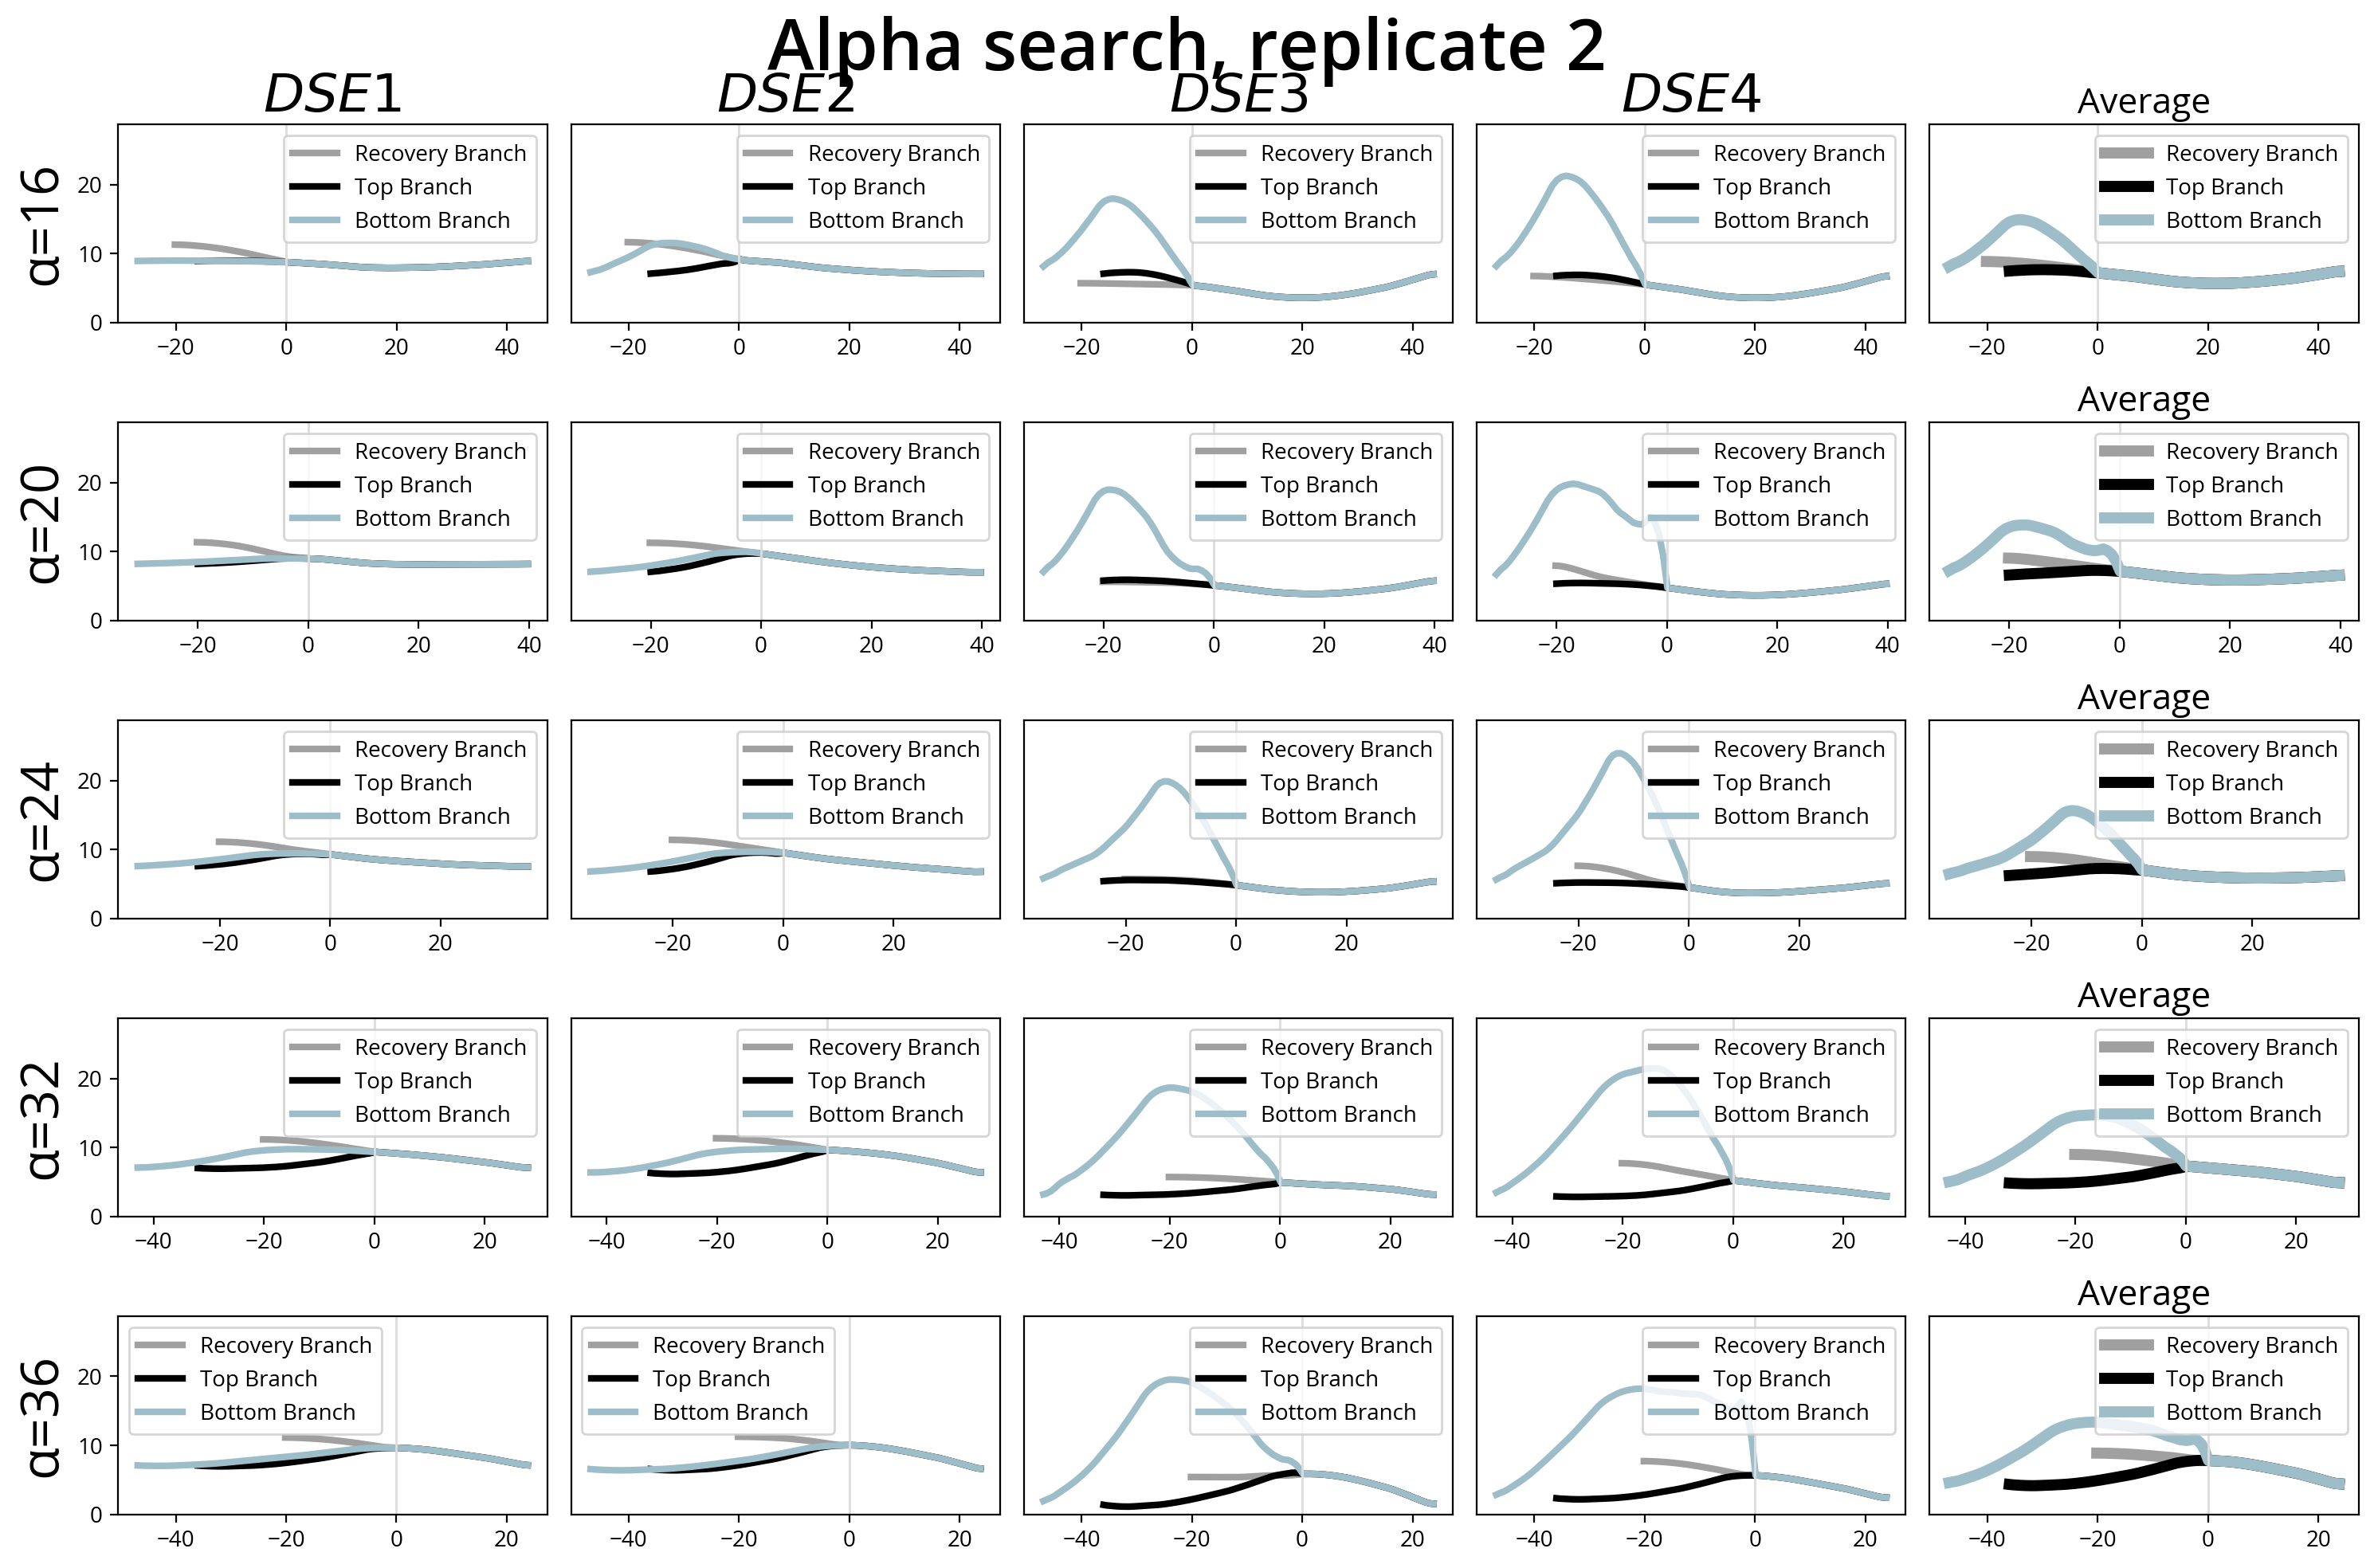

In [2274]:
from src.alpha_search import FindAlphaSweepDS

finder = FindAlphaSweepDS(output_directory='output/draft3_run/', 
    gene_names=['DSE1', 'DSE2', 'DSE3', 'DSE4'])
finder.run_alpha_sweep(alphas=[16, 20, 24, 32, 36])
finder.plot_and_save_results(save=False)


In [2275]:
finder.runner.config2.modify_alpha(16)
finder.runner.deconvolve_gene_find_gamma('DSE3', replicate=2, verbose=True)

	Base error (γ=0):	rn: 0.326901	sn: 7632.113372
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.343247
			Absolute (e0 + 0.04): 0.366901
			Chosen: 0.343247
		Right:
			Relative (4.00 * e0): 1.30761
			Absolute (e0 + 11.32): 11.6469
			Chosen: 11.646901
	Searching for left boundary gamma...
		γ: 0.5005	rn: 18.0168	sn: 64.4217
		γ: 0.25075	rn: 17.3988	sn: 66.0967
		γ: 0.125875	rn: 11.2538	sn: 106.3220
		γ: 0.0634375	rn: 3.9950	sn: 183.6858
		γ: 0.0322187	rn: 2.0094	sn: 225.1907
		γ: 0.0166094	rn: 1.5012	sn: 246.0110
		γ: 0.00880469	rn: 1.2417	sn: 267.1860
		γ: 0.00490234	rn: 1.1335	sn: 283.8059
		γ: 0.00295117	rn: 0.9998	sn: 322.7017
		γ: 0.00197559	rn: 0.8449	sn: 383.9984
		γ: 0.00148779	rn: 0.8204	sn: 398.1905
		γ: 0.0012439	rn: 0.8123	sn: 404.1429
		γ: 0.00112195	rn: 0.7578	sn: 450.5721
		γ: 0.00106097	rn: 0.7246	sn: 481.0314
		γ: 0.00103049	rn: 0.7086	sn: 496.3043
		γ: 0.00101524	rn: 0.7008	sn: 503.8639
		γ: 0.00100762	rn: 0.6970	sn: 507.6723
		γ: 0.00100381	rn: 0.6951	sn: 509

In [2269]:
finder.runner.expression_find_gamma.gamma_optimizer.gamma_left,\
finder.runner.expression_find_gamma.gamma_optimizer.gamma_right

(0.0010004763603210448, 0.12837868910871822)

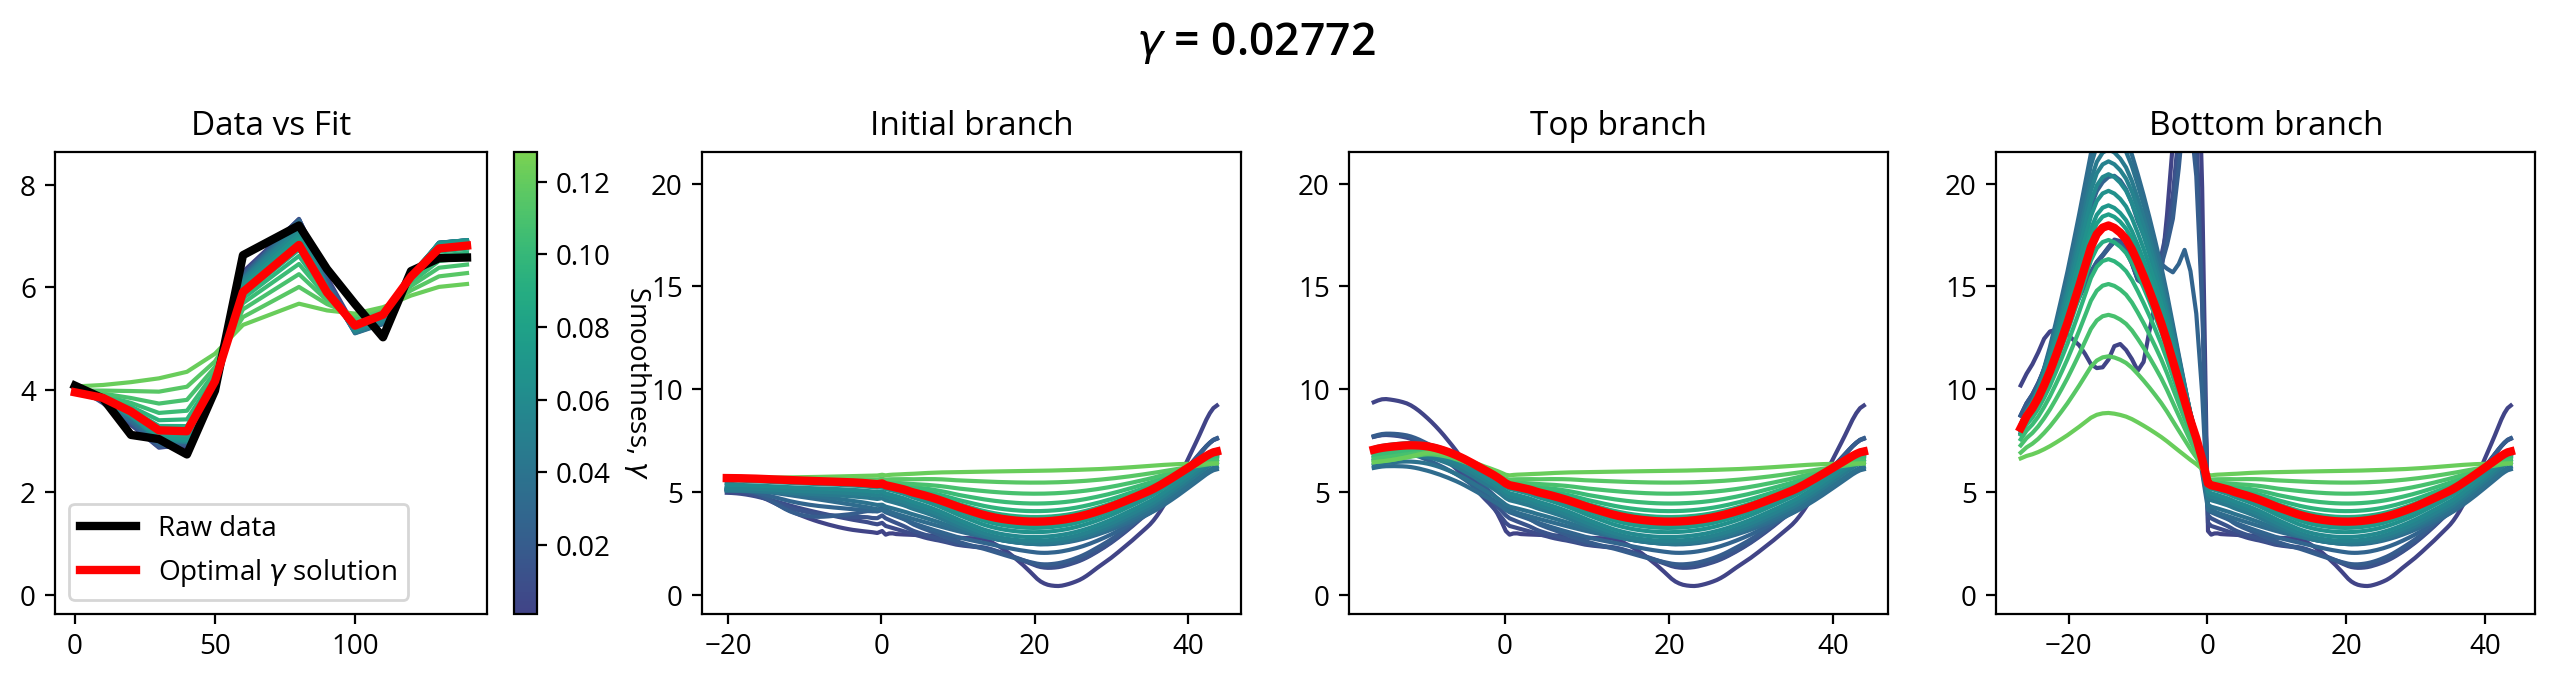

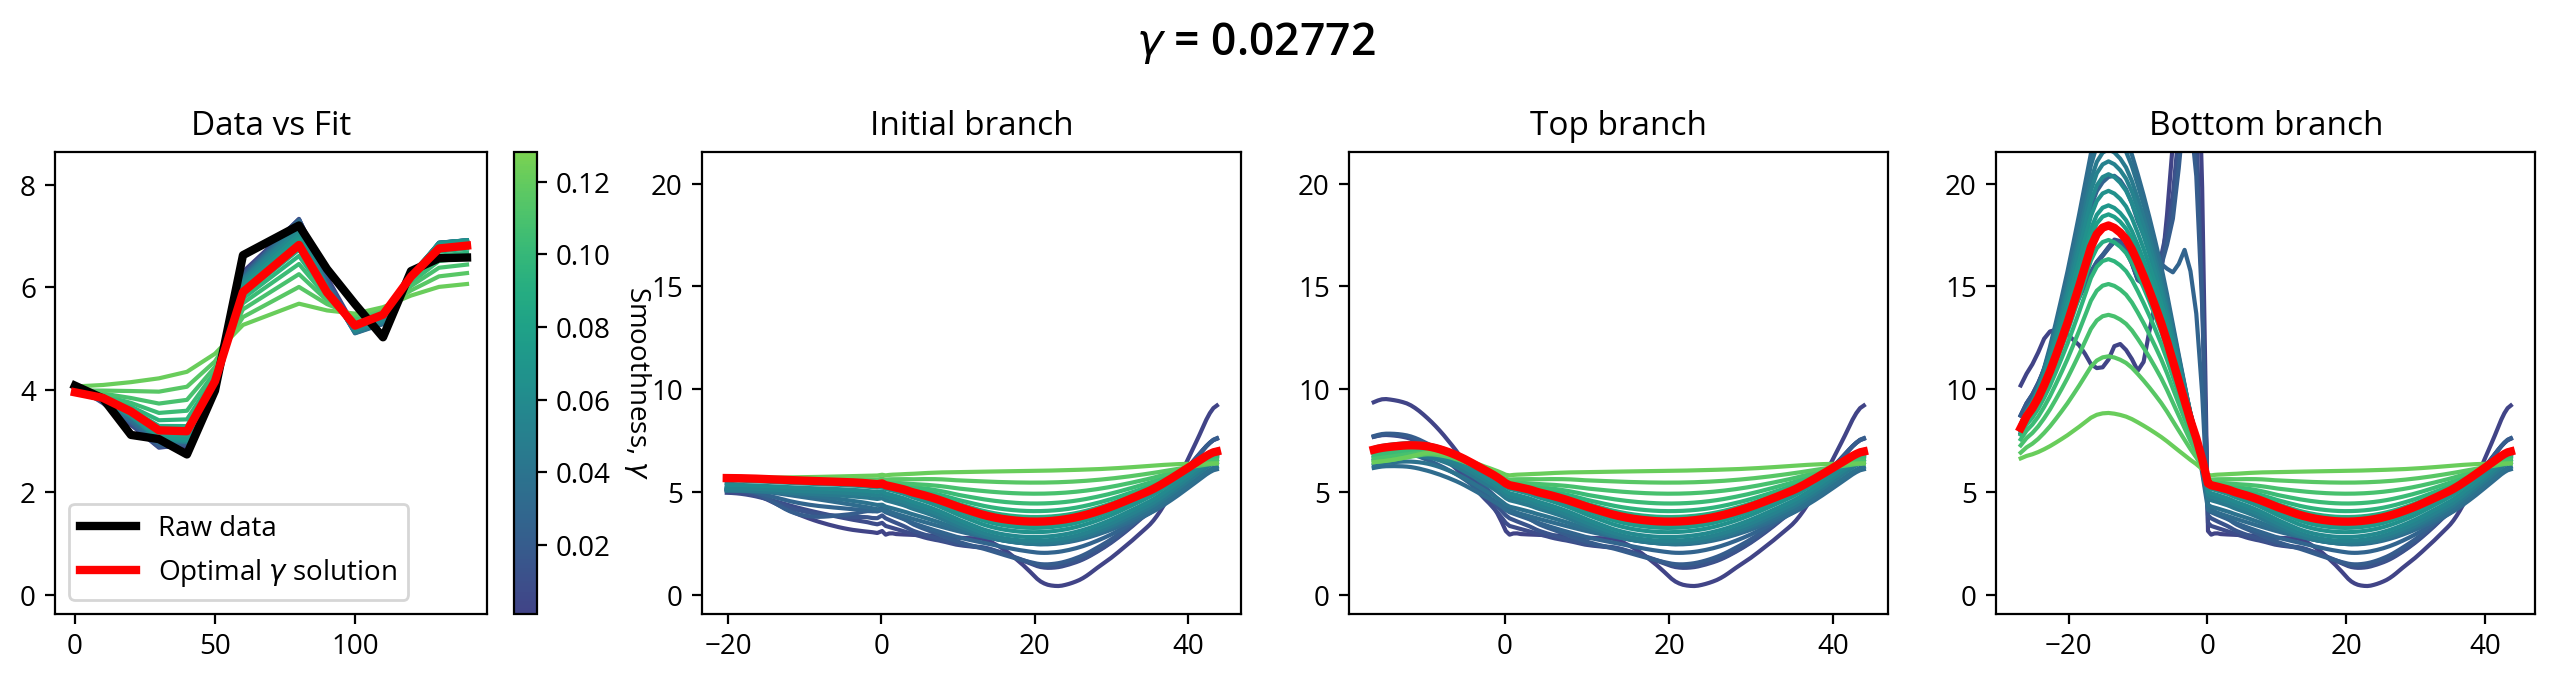

In [2270]:
finder.runner.expression_find_gamma.plot_gamma_sweep()

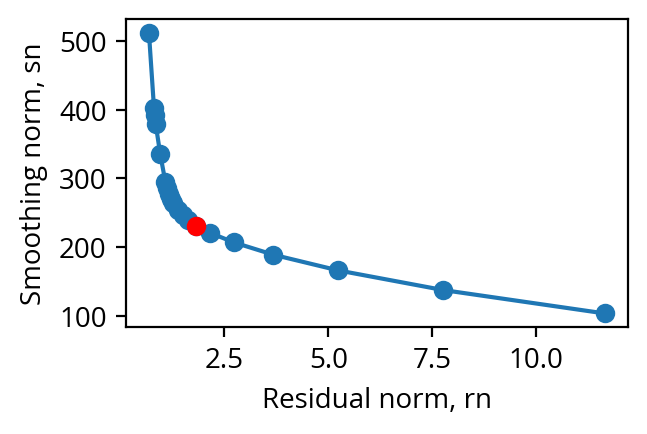

In [2271]:
finder.runner.expression_find_gamma.gamma_optimizer.plot_elbow()

In [2272]:
finder.runner.expression_find_gamma.deconvolution_solver.gamma = 0.03
finder.runner.expression_find_gamma.deconvolution_solver.deconvolve()

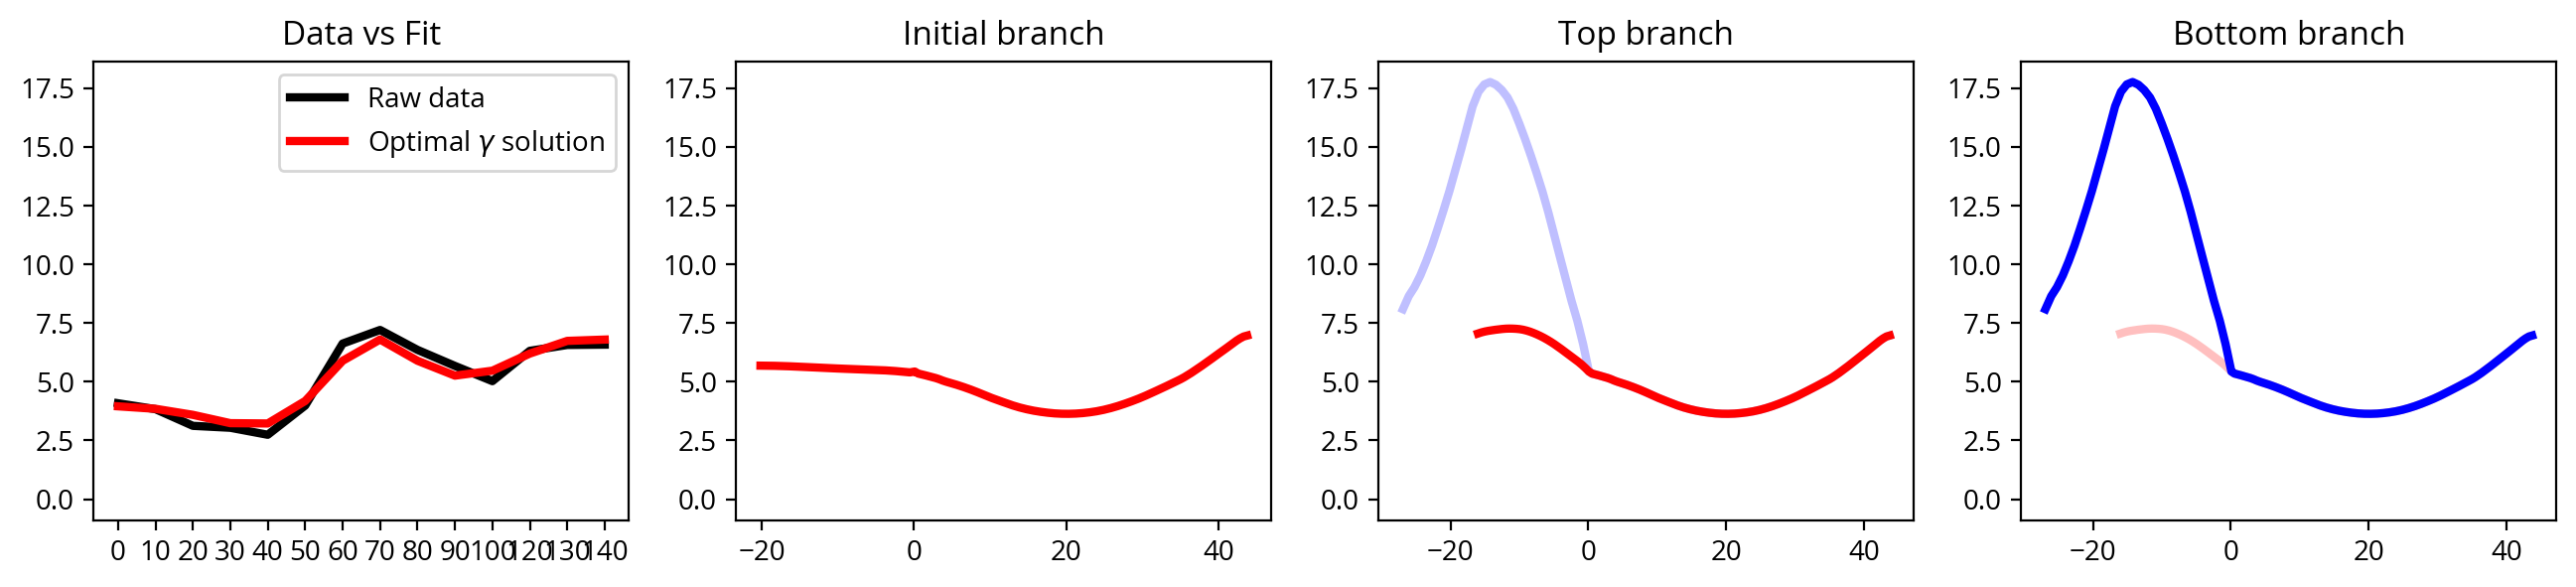

In [2273]:
finder.runner.expression_find_gamma.deconvolution_solver.plot_fit(True)